In [5]:
import json

def check_coco_classes(json_path):
    """Loads a COCO annotation file and lists all classes."""
    try:
        with open(json_path, 'r') as f:
            data = json.load(f)
        
        categories = data.get('categories', [])
        print(f"=== Dataset Inspection ===")
        print(f"Path: {json_path}")
        print(f"Total classes found: {len(categories)}\n")
        print("Class List:")
        for cat in categories:
            print(f"  - ID {cat['id']}: {cat['name']}")
            
    except FileNotFoundError:
        print(f"Error: Could not find the JSON file at {json_path}. Please check your path.")
    except Exception as e:
        print(f"An error occurred: {e}")

# --- UPDATE PATH HERE ---
# Example path relative to your 'src' folder targeting the unzipped CarDD dataset
json_file_path = "/Users/macbook/Documents/ITC8/Internship/AI Farm/Project/car_defect_detection/data/raw/CarDD_release/CarDD_COCO/annotations/instances_train2017.json"

check_coco_classes(json_file_path)

=== Dataset Inspection ===
Path: /Users/macbook/Documents/ITC8/Internship/AI Farm/Project/car_defect_detection/data/raw/CarDD_release/CarDD_COCO/annotations/instances_train2017.json
Total classes found: 6

Class List:
  - ID 1: dent
  - ID 2: scratch
  - ID 3: crack
  - ID 4: glass shatter
  - ID 5: lamp broken
  - ID 6: tire flat


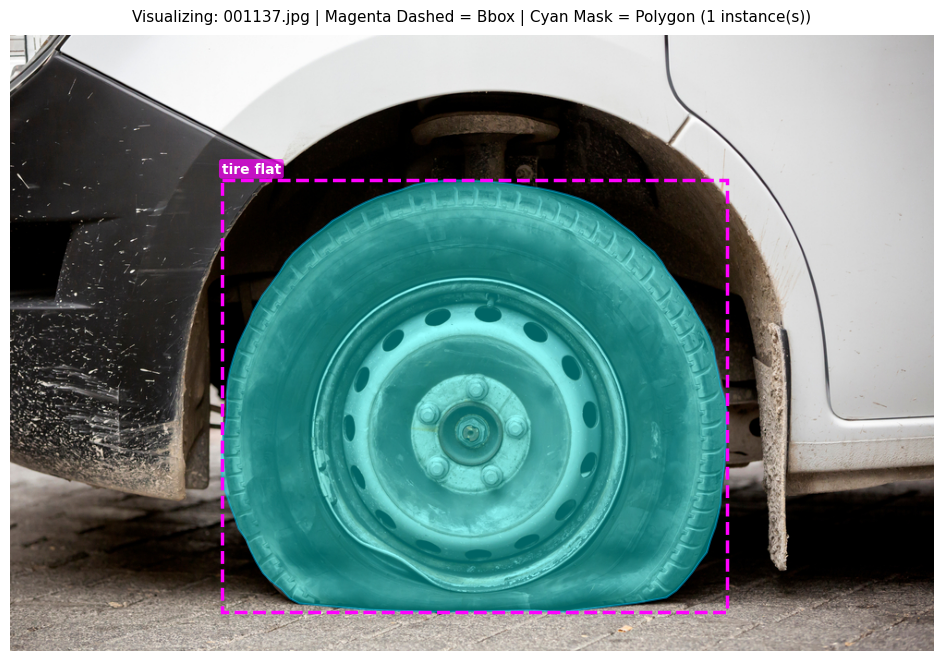

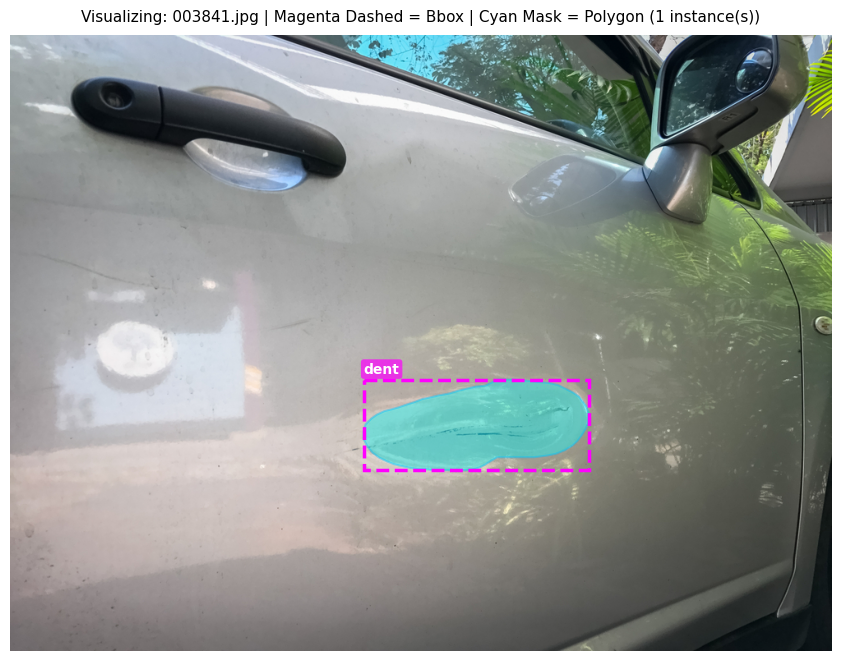

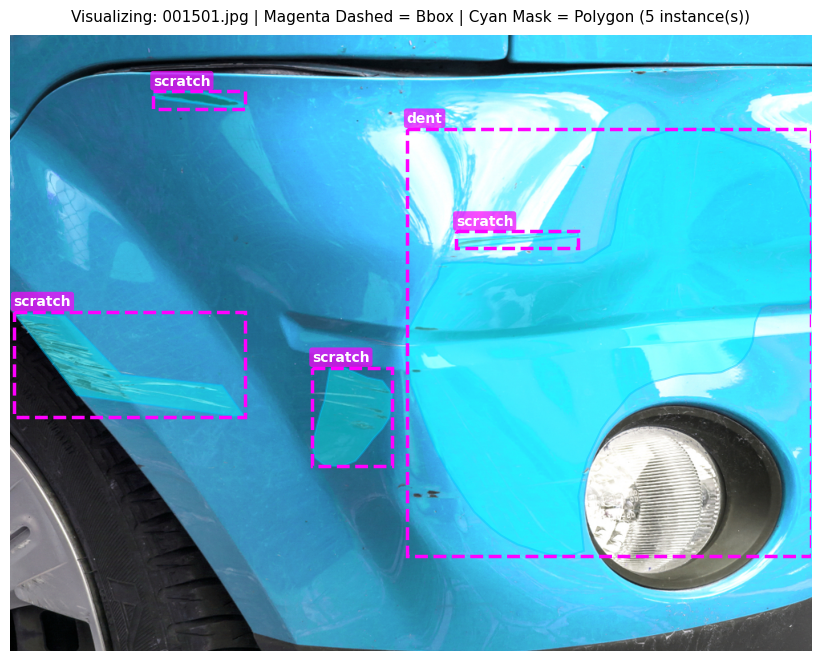

In [27]:
import json
import os
import random
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_coco_both(json_path, img_dir, num_images=3):
    """Selects random images from a COCO dataset and overlays BOTH bounding boxes and polygon masks."""
    # 1. Load JSON file
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    # Map category IDs to names
    categories = {cat['id']: cat['name'] for cat in data.get('categories', [])}
    images = data.get('images', [])
    annotations = data.get('annotations', [])
    
    if not images:
        print("No images found in the annotation file.")
        return
        
    # 2. Pick random images
    sampled_images = random.sample(images, min(num_images, len(images)))
    
    # 3. Plot each image
    for img_info in sampled_images:
        img_id = img_info['id']
        file_name = img_info['file_name']
        img_path = os.path.join(img_dir, file_name)
        
        # Load image using OpenCV
        img = cv2.imread(img_path)
        if img is None:
            print(f"Warning: Could not load image at {img_path}")
            continue
            
        # Convert BGR (OpenCV default) to RGB for Matplotlib
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Filter annotations for this specific image
        img_anns = [ann for ann in annotations if ann['image_id'] == img_id]
        
        # Setup plot
        plt.figure(figsize=(12, 8))
        ax = plt.gca()
        ax.imshow(img)
        
        # Draw annotations
        for ann in img_anns:
            cat_id = ann.get('category_id')
            class_name = categories.get(cat_id, f"Unknown ({cat_id})")
            
            # --- 1. DRAW POLYGON SEGMENTATION (The actual defect shape) ---
            segmentations = ann.get('segmentation', [])
            if isinstance(segmentations, list):
                for seg in segmentations:
                    # COCO format is a flat list: [x1, y1, x2, y2, ...]
                    # Reshape it into pairs of [[x1, y1], [x2, y2], ...]
                    poly_points = [[seg[i], seg[i+1]] for i in range(0, len(seg), 2)]
                    
                    # Create a semi-transparent filled polygon for the mask
                    polygon_patch = patches.Polygon(
                        poly_points, 
                        closed=True, 
                        facecolor='cyan', 
                        alpha=0.4, 
                        edgecolor='deepskyblue', 
                        linewidth=1.5
                    )
                    ax.add_patch(polygon_patch)

            # --- 2. DRAW RECTANGULAR BOUNDING BOX ---
            bbox = ann.get('bbox', [])  # [x_min, y_min, width, height]
            if len(bbox) == 4:
                x, y, w, h = bbox
                # Create a bright dashed rectangle around the polygon
                rect = patches.Rectangle(
                    (x, y), w, h, 
                    fill=False, 
                    edgecolor='magenta', 
                    linestyle='--', 
                    linewidth=2.5
                )
                ax.add_patch(rect)
                
                # Add text label above the bounding box
                ax.text(
                    x, y - 8, f"{class_name}", 
                    bbox=dict(facecolor='magenta', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'), 
                    fontsize=10, color='white', weight='bold'
                )
                
        plt.title(f"Visualizing: {file_name} | Magenta Dashed = Bbox | Cyan Mask = Polygon ({len(img_anns)} instance(s))", fontsize=11, pad=10)
        plt.axis('off')
        plt.show()

# --- UPDATE YOUR PATHS HERE ---
json_file_path = "/Users/macbook/Documents/ITC8/Internship/AI Farm/Project/car_defect_detection/data/raw/CarDD_release/CarDD_COCO/annotations/instances_train2017.json"
image_folder_path = "/Users/macbook/Documents/ITC8/Internship/AI Farm/Project/car_defect_detection/data/raw/CarDD_release/CarDD_COCO/train2017"

visualize_coco_both(json_file_path, image_folder_path, num_images=3)